In [2]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
font_manager.fontManager.addfont("/home/tx82/Arial.ttf")
plt.rcParams['font.family'] = 'Arial'

import sys
sys.path.append("../")
from utils import *

In [8]:
root_dir = "/fs/cbsuhy02/storage/tx82/"

# define all the INPUT paths
rna_celline_hpa_file = os.path.join(root_dir, "_DATA/_COMMON/reggenome/expression/HPA/rna_celline_hpa.tsv")
rna_brain_region_hpa_file = os.path.join(root_dir, "_DATA/_COMMON/reggenome/expression/HPA/rna_brain_region_hpa.tsv")

# define all the OUTPUT paths
fig4c_file = "Fig4c.png"
fig4c_data_file = "Fig4c_data.csv"


# Fig 4C - Expression levels of RIN2 and RIN3 across representative human cell lines and selected human brain regions

In [7]:
# load TPM for selected cell lines (hpa) and brain regions (hpa)
# RIN2 vs. RIN3
expression_feat = "TPM"

# cell lines: HEK293, HCT 116
rna_celline_hpa = pd.read_table(rna_celline_hpa_file)
cell_lines_list = ["HEK293", "HCT 116"]
rna_celline_hpa_df = rna_celline_hpa[rna_celline_hpa["Cell line"].isin(cell_lines_list)].reset_index(drop=True)[["Gene", "Gene name", "Cell line", expression_feat]].pivot(index=['Gene', "Gene name"], columns="Cell line", values=expression_feat).reset_index().rename_axis(None, axis=1)

# brain regions: amygdala, cerebellum, cerebral cortex, hippocampal formation, thalamus
rna_brain_region_hpa = pd.read_table(rna_brain_region_hpa_file)
brain_regions_list = ["amygdala", "cerebellum", "cerebral cortex", "hippocampal formation", "thalamus"]
rna_brain_region_hpa_df = rna_brain_region_hpa[rna_brain_region_hpa["Brain region"].isin(brain_regions_list)].reset_index(drop=True)[["Gene", "Gene name", "Brain region", expression_feat]].pivot(index=['Gene', "Gene name"], columns="Brain region", values=expression_feat).reset_index().rename_axis(None, axis=1)

gene_list = ["RIN2", "RIN3"]
rna_datasets_merged_df = pd.merge(rna_celline_hpa_df, rna_brain_region_hpa_df, on="Gene", how="inner").drop(columns=["Gene name_y"]).rename(columns={"Gene name_x": "Gene name"})
rna_datasets_merged_df_melted = rna_datasets_merged_df[rna_datasets_merged_df["Gene name"].isin(gene_list)].melt(id_vars=["Gene", "Gene name"], value_vars=['HCT 116', 'HEK293', "amygdala", "cerebellum", "cerebral cortex", "hippocampal formation", "thalamus"]).rename(columns={"variable":"Sample", "value":expression_feat})
rna_datasets_merged_df_melted.to_csv(fig4c_data_file, sep=',', index=False)
display(rna_datasets_merged_df_melted)

,Gene,Gene name,Sample,TPM
0,ENSG00000100599,RIN3,HCT 116,9.8
1,ENSG00000132669,RIN2,HCT 116,0.3
2,ENSG00000100599,RIN3,HEK293,3.4
3,ENSG00000132669,RIN2,HEK293,0.1
4,ENSG00000100599,RIN3,amygdala,12.8
5,ENSG00000132669,RIN2,amygdala,22.7
6,ENSG00000100599,RIN3,cerebellum,14.6
7,ENSG00000132669,RIN2,cerebellum,26.9
8,ENSG00000100599,RIN3,cerebral cortex,18.8
9,ENSG00000132669,RIN2,cerebral cortex,23.5


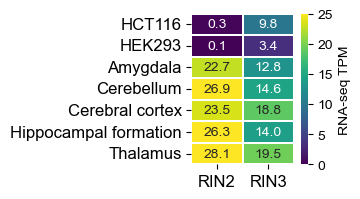

In [10]:
sample_order = ['HCT 116', 'HEK293', "amygdala", "cerebellum", "cerebral cortex",
                "hippocampal formation", "thalamus"]
sample_labels = ['HCT116', 'HEK293', "Amygdala", "Cerebellum", "Cerebral cortex",
                 "Hippocampal formation", "Thalamus"]

# pivot to gene x sample matrix
df = pd.read_table(fig4c_data_file, sep=',')
mat = (df.pivot(index="Gene name", columns="Sample", values=expression_feat)
         .reindex(index=gene_list, columns=sample_order))
mat_log = np.log2(mat + 1)

# plot heatmap
fig, ax = plt.subplots(figsize=(3.5,2.1))

sns.heatmap(
    mat.T,
    ax=ax,
    vmin=0, vmax=25,
    cmap="viridis",          
    linewidths=1.2,
    linecolor="white",
    cbar_kws={"label": f"RNA-seq {expression_feat}"},
    # cbar_kws={"label": f"log2({expression_feat} + 1)"},
    annot=True, fmt=".1f"    
)

# set x/y labels and ticks
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=12)
ax.set_yticklabels(sample_labels, fontsize=12)

plt.tight_layout()
fig.savefig(fig4c_file, bbox_inches='tight', dpi=500)
fig.savefig(fig4c_file.replace(".png", ".svg"), format="svg", bbox_inches='tight', dpi=500)